# Support Vector Machines: Introduction

## Learning Objectives

1. **Define** the functional margin $\hat{\gamma}_i = y_i(\mathbf{w}\cdot\mathbf{x}_i + b)$ and geometric margin $\gamma_i = \hat{\gamma}_i / \|\mathbf{w}\|$
2. **Derive** the hard-margin SVM: $\min \|\mathbf{w}\|^2$ s.t. $y_i(\mathbf{w}\cdot\mathbf{x}_i) \geq 1$ from the maximum-margin principle
3. **Extend** to soft-margin SVM via slack variables $\xi_i \geq 0$ and hinge loss
4. **Show** the natural form: $f(\mathbf{w}) = \tfrac{1}{2}\mathbf{w}\cdot\mathbf{w} + C\sum_i \max\{0, 1 - y_i(\mathbf{x}_i\cdot\mathbf{w})\}$
5. **Implement** a soft-margin SVM with subgradient descent and verify on linearly separable and non-separable data


## Problem Statement

### Maximum Margin Classifier

Given a binary classification problem with labels $y_i \in \{-1,+1\}$, many hyperplanes $\mathbf{w}\cdot\mathbf{x}+b=0$ may correctly classify the data. The SVM selects the one with **maximum geometric margin**:

$$\gamma_i = \frac{y_i(\mathbf{w}\cdot\mathbf{x}_i + b)}{\|\mathbf{w}\|} \geq \gamma \quad \forall i$$

Maximising $\gamma = \min_i \gamma_i$ subject to constraints.

### Canonical Form

Using canonical hyperplanes (scale $\mathbf{w}$ so that $\min_i y_i(\mathbf{w}\cdot\mathbf{x}_i) = 1$), the geometric margin becomes $1/\|\mathbf{w}\|$. The hard-margin SVM:

$$\min_{\mathbf{w}} \|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}\cdot\mathbf{x}_i) \geq 1 \quad \forall i$$

(bias $b$ absorbed into $\mathbf{w}$ with an augmented feature).

### Soft-Margin SVM

For non-separable data, introduce slack variables $\xi_i \geq 0$:
$$\min_{\mathbf{w},\boldsymbol{\xi}} \|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{s.t.} \quad y_i(\mathbf{w}\cdot\mathbf{x}_i) \geq 1 - \xi_i,\; \xi_i \geq 0$$

Eliminating $\xi_i$ (since $\xi_i = \max\{0, 1 - y_i(\mathbf{w}\cdot\mathbf{x}_i)\}$ at optimum):
$$f(\mathbf{w}) = \frac{1}{2}\mathbf{w}\cdot\mathbf{w} + C\sum_i \underbrace{\max\{0, 1 - y_i(\mathbf{x}_i\cdot\mathbf{w})\}}_{\text{hinge loss}}$$

Trade-off: large $C$ $\to$ less regularisation (fit training data tightly); small $C$ $\to$ larger margin (tolerate more misclassifications).


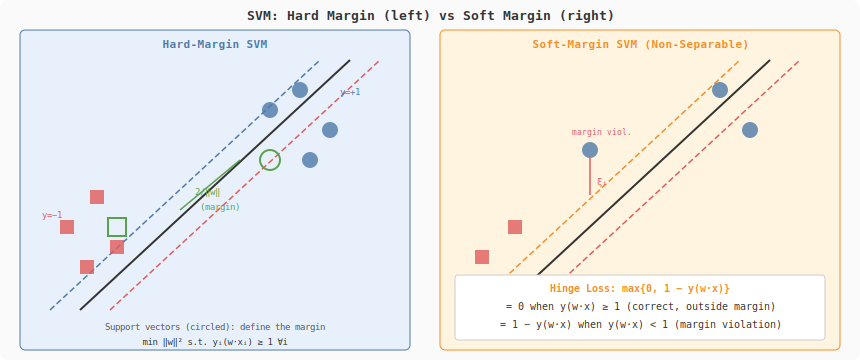

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="360" font-family="monospace" font-size="11">
  <rect width="860" height="360" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">SVM: Hard Margin (left) vs Soft Margin (right)</text>

  <!-- ── Hard Margin ── -->
  <rect x="20" y="30" width="390" height="320" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="215" y="48" text-anchor="middle" fill="#4e79a7" font-weight="bold">Hard-Margin SVM</text>

  <!-- Decision boundary and margins -->
  <!-- Hyperplane w·x = 0 (diagonal) -->
  <line x1="80"  y1="310" x2="350" y2="60"  stroke="#333" stroke-width="2"/>
  <!-- Margin planes w·x = +1 and w·x = -1 -->
  <line x1="50"  y1="310" x2="320" y2="60"  stroke="#4e79a7" stroke-width="1.5" stroke-dasharray="6,3"/>
  <line x1="110" y1="310" x2="380" y2="60"  stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="6,3"/>

  <!-- Margin annotation -->
  <line x1="240" y1="160" x2="180" y2="210" stroke="#59a14f" stroke-width="1.5"/>
  <text x="195" y="195" fill="#59a14f" font-size="9">2/‖w‖</text>
  <text x="200" y="210" fill="#59a14f" font-size="9">(margin)</text>

  <!-- Positive class (blue circles, right side) -->
  <circle cx="300" cy="90"  r="8" fill="#4e79a7" opacity="0.8"/>
  <circle cx="330" cy="130" r="8" fill="#4e79a7" opacity="0.8"/>
  <circle cx="270" cy="110" r="8" fill="#4e79a7" opacity="0.8"/>
  <circle cx="310" cy="160" r="8" fill="#4e79a7" opacity="0.8"/>
  <text x="340" y="95" fill="#4e79a7" font-size="9">y=+1</text>

  <!-- Negative class (red squares, left side) -->
  <rect x="90"  y="190" width="14" height="14" fill="#e05c5c" opacity="0.8"/>
  <rect x="60"  y="220" width="14" height="14" fill="#e05c5c" opacity="0.8"/>
  <rect x="110" y="240" width="14" height="14" fill="#e05c5c" opacity="0.8"/>
  <rect x="80"  y="260" width="14" height="14" fill="#e05c5c" opacity="0.8"/>
  <text x="42" y="218" fill="#e05c5c" font-size="9">y=−1</text>

  <!-- Support vectors -->
  <circle cx="270" cy="160" r="10" fill="none" stroke="#59a14f" stroke-width="2"/>
  <rect x="108" y="218" width="18" height="18" fill="none" stroke="#59a14f" stroke-width="2"/>
  <text x="215" y="330" text-anchor="middle" fill="#555" font-size="9">Support vectors (circled): define the margin</text>
  <text x="215" y="345" text-anchor="middle" fill="#333" font-size="9">min ‖w‖² s.t. yᵢ(w·xᵢ) ≥ 1 ∀i</text>

  <!-- ── Soft Margin ── -->
  <rect x="440" y="30" width="400" height="320" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="640" y="48" text-anchor="middle" fill="#f28e2b" font-weight="bold">Soft-Margin SVM (Non-Separable)</text>

  <!-- Decision boundary -->
  <line x1="500" y1="310" x2="770" y2="60" stroke="#333" stroke-width="2"/>
  <line x1="470" y1="310" x2="740" y2="60" stroke="#f28e2b" stroke-width="1.5" stroke-dasharray="6,3"/>
  <line x1="530" y1="310" x2="800" y2="60" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="6,3"/>

  <!-- Points on correct side -->
  <circle cx="720" cy="90"  r="8" fill="#4e79a7" opacity="0.8"/>
  <circle cx="750" cy="130" r="8" fill="#4e79a7" opacity="0.8"/>
  <rect x="508" y="220" width="14" height="14" fill="#e05c5c" opacity="0.8"/>
  <rect x="475" y="250" width="14" height="14" fill="#e05c5c" opacity="0.8"/>

  <!-- Misclassified point (inside margin) -->
  <circle cx="590" cy="150" r="8" fill="#4e79a7" opacity="0.8"/>
  <line x1="590" y1="158" x2="590" y2="195" stroke="#e05c5c" stroke-width="1.5"/>
  <text x="597" y="185" fill="#e05c5c" font-size="9">ξᵢ</text>
  <text x="572" y="135" fill="#e05c5c" font-size="8">margin viol.</text>

  <!-- Hinge loss diagram -->
  <rect x="455" y="275" width="370" height="65" rx="3" fill="#fff" stroke="#ccc"/>
  <text x="640" y="292" text-anchor="middle" fill="#f28e2b" font-size="10" font-weight="bold">Hinge Loss:  max{0, 1 − y(w·x)}</text>
  <text x="640" y="310" text-anchor="middle" fill="#333" font-size="10">= 0  when  y(w·x) ≥ 1  (correct, outside margin)</text>
  <text x="640" y="328" text-anchor="middle" fill="#333" font-size="10">= 1 − y(w·x)  when  y(w·x) &lt; 1  (margin violation)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### From Maximum Margin to Optimisation

**Step 1**: Maximum margin $\equiv$ minimum $\|\mathbf{w}\|$ subject to $y_i(\mathbf{w}\cdot\mathbf{x}_i) \geq 1$.

With $\min_i y_i(\mathbf{w}\cdot\mathbf{x}_i) = 1$ (canonical form), margin $= 1/\|\mathbf{w}\|$. Maximising $1/\|\mathbf{w}\| \equiv$ minimising $\|\mathbf{w}\|^2$.

**Step 2**: Dual formulation (Lagrangian):
$$\mathcal{L} = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_i \alpha_i [y_i(\mathbf{w}\cdot\mathbf{x}_i) - 1]$$

Setting $\partial \mathcal{L}/\partial \mathbf{w} = 0$: $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ — the solution is a linear combination of **support vectors** (those with $\alpha_i > 0$).

### Soft-Margin Derivation

Slack variables $\xi_i \geq 0$ allow constraint violation:
$$y_i(\mathbf{w}\cdot\mathbf{x}_i) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

At optimum, $\xi_i = \max\{0, 1 - y_i(\mathbf{w}\cdot\mathbf{x}_i)\}$ (hinge loss). Substituting:
$$f(\mathbf{w}) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{m}\sum_i \max\{0, 1 - y_i(\mathbf{w}\cdot\mathbf{x}_i)\}$$

where $\lambda = 1/(mC)$. This is the primal form used in PEGASOS (next notebook).

### Subgradient

Hinge loss $\ell(z) = \max(0, 1-z)$:
$$\partial \ell / \partial w_j = \begin{cases} 0 & \text{if } z \geq 1 \\ -y_i x_{ij} & \text{if } z < 1 \end{cases}$$


In [2]:
import numpy as np


class SVM:
    """
    Soft-margin SVM with subgradient descent.
    Objective: (λ/2)‖w‖² + (1/m)Σ max{0, 1 − yᵢ(xᵢ·w)}
    """

    def __init__(self, C=1.0, lr=0.01, max_iter=1000, seed=0):
        self.C = C
        self.lr = lr
        self.max_iter = max_iter
        self.seed = seed
        self.w = None

    def fit(self, X, y):
        """y must be in {-1, +1}."""
        n, d = X.shape
        rng  = np.random.default_rng(self.seed)
        lam  = 1.0 / (n * self.C)
        self.w = rng.normal(0, 0.01, d)
        losses = []

        for t in range(1, self.max_iter + 1):
            eta = self.lr / np.sqrt(t)   # decaying step size
            scores = X @ self.w          # shape (n,)
            margin = y * scores
            active = margin < 1          # hinge active

            # Subgradient of full objective
            g = lam * self.w - (1/n) * (y[active, None] * X[active]).sum(axis=0)
            self.w -= eta * g

            loss = 0.5 * lam * np.dot(self.w, self.w) + \
                   np.maximum(0, 1 - margin).mean()
            losses.append(loss)

        return losses

    def predict(self, X):
        return np.sign(X @ self.w).astype(int)

    def decision_function(self, X):
        return X @ self.w


# ── Test 1: linearly separable ────────────────────────────────────────────────
rng = np.random.default_rng(0)
X_sep = rng.standard_normal((200, 2))
y_sep = np.where(X_sep[:,0] - X_sep[:,1] > 0, 1, -1)

svm_sep = SVM(C=1.0, lr=0.5, max_iter=500)
losses_sep = svm_sep.fit(X_sep, y_sep)
print(f"Separable:      acc = {(svm_sep.predict(X_sep)==y_sep).mean():.2%}, "
      f"final loss = {losses_sep[-1]:.4f}")

# ── Test 2: non-separable (overlap) ───────────────────────────────────────────
X_ns = rng.standard_normal((200, 2))
y_ns = np.where(X_ns[:,0] - X_ns[:,1] + rng.normal(0,0.8,200) > 0, 1, -1)

svm_ns = SVM(C=1.0, lr=0.5, max_iter=500)
losses_ns = svm_ns.fit(X_ns, y_ns)
print(f"Non-separable:  acc = {(svm_ns.predict(X_ns)==y_ns).mean():.2%}, "
      f"final loss = {losses_ns[-1]:.4f}")

# ── Effect of C ───────────────────────────────────────────────────────────────
print("\nEffect of C on margin (‖w‖ ∝ 1/margin):")
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    svm_c = SVM(C=C, lr=0.5, max_iter=1000)
    svm_c.fit(X_sep, y_sep)
    print(f"  C={C:6.2f}: ‖w‖={np.linalg.norm(svm_c.w):.3f}, "
          f"margin≈{1/np.linalg.norm(svm_c.w):.3f}, "
          f"acc={( svm_c.predict(X_sep)==y_sep).mean():.2%}")


Separable:      acc = 100.00%, final loss = 0.1343
Non-separable:  acc = 88.50%, final loss = 0.2950

Effect of C on margin (‖w‖ ∝ 1/margin):
  C=  0.01: ‖w‖=0.844, margin≈1.185, acc=100.00%
  C=  0.10: ‖w‖=2.087, margin≈0.479, acc=100.00%
  C=  1.00: ‖w‖=3.097, margin≈0.323, acc=100.00%
  C= 10.00: ‖w‖=3.304, margin≈0.303, acc=100.00%
  C=100.00: ‖w‖=3.325, margin≈0.301, acc=100.00%
